## Instructions for Accessing and Specifying Intended Use for AmeriFlux Data

1.   **Finding site IDs:** If you're not sure what site IDs you need, look at https://ameriflux.lbl.gov/sites/site-search/?mapping-tool and find the names on the map. 

1.   **Data avilibility:** Varibles within a site's dataset have different temporal scales, policies and levels of processing pipelines.  Please use "data_aval_plot.R" to better understand you site's data. 

1.   **Access the AmeriFlux FLUXNET Website:** Navigate to the AmeriFlux FLUXNET website https://fluxnet.org/data/download-data/ .

1.   **Log In:** Enter your credentials to log in to your AmeriFlux account.

1.   **Select AmeriFlux Base:** Once logged in, select the "AmeriFlux Base" option or dataset from the available choices.

1.   **Acknowledge License:** Select the "CC-BY-4.0" Creative Commons license. By proceeding, you acknowledge and agree to these terms.

1.   **Search for Sites by Site ID:** In the designated field, enter the Site ID(s) for the specific AmeriFlux site(s) you are interested in. Follow any specified formatting and order to ensure the best filter results. 

1.   **Specify Intended Use:** Locate the section or form where you can provide information about your intended use of the AmeriFlux data. Fill out this section with a clear and concise description of how you plan to use the data. Be as specific as possible.


## Creating NetCDF

This combines all our sites into one netCDF.  Due to the large amount of data this can take 10 mins for the code run and finish. 

In [ ]:
# import libraries
import pandas as pd
import xarray as xr
from datetime import datetime
import os
import numpy as np  # Import NumPy

def main():
    """
    Main function to orchestrate the data processing and saving using local variables.
    """
    # Local Variables
    csv_files = [
        "FLX_US-Me1_FLUXNET2015_FULLSET_HH_2004-2005_1-4.csv",
        "AMF_US-Me2_FLUXNET_FULLSET_HH_2002-2022_4-6.csv",
        "FLX_US-Me3_FLUXNET2015_FULLSET_HH_2004-2009_1-4.csv",
        "FLX_US-Me4_FLUXNET2015_FULLSET_HH_1996-2000_1-4.csv",
        "FLX_US-Me5_FLUXNET2015_FULLSET_HH_2000-2002_1-4.csv",
        "AMF_US-Me6_FLUXNET_FULLSET_HH_2010-2022_4-6.csv"
    ]
    output_filename_30min = 'fluxnet_estimates_30minc.nc'
    working_directory = "C:/directory_here"  # Set this appropriately

    os.chdir(working_directory)
    start_time = datetime.now()

    try:
        # Read CSV files into a list of DataFrames
        dfs = [pd.read_csv(file) for file in csv_files]
        # Add 'Site' column to each DataFrame
        for df, file in zip(dfs, csv_files):
            site_name = file.split('_')[1]
            df['Site'] = site_name
        # Concatenate all DataFrames into one
        ds_pd = pd.concat(dfs, ignore_index=True)

        # Extract date and time components from 'TIMESTAMP_END' into a NumPy array for speed
        timestamp_end = ds_pd['TIMESTAMP_END'].astype(str) # Convert to string for slicing
        ds_pd[['year', 'Month', 'DD', 'Hour', 'Min']] = pd.DataFrame({
            'year': timestamp_end.str[:4],
            'Month': pd.to_numeric(timestamp_end.str[4:6]),
            'DD': pd.to_numeric(timestamp_end.str[6:8]),
            'Hour': timestamp_end.str[8:10],
            'Min': timestamp_end.str[10:12]
        })

        # Create 'rDate' and 'date' columns as datetime objects
        ds_pd['rDate'] = pd.to_datetime(ds_pd[['year', 'Month', 'DD', 'Hour', 'Min']].astype(str).agg('/'.join, axis=1), format='%Y/%m/%d/%H/%M', utc=True)
        ds_pd['date'] = pd.to_datetime(ds_pd[['year', 'Month', 'DD']].astype(str).agg('/'.join, axis=1), format='%Y/%m/%d', utc=True)
        
        # Calculate 'loop' day number
        ds_pd['loop'] = (ds_pd['date'] - ds_pd['date'].min()).dt.days + 1

        # Get unique days to process
        days_to_run = ds_pd['loop'].unique()

        # Use a generator expression for memory efficiency.  This avoids creating a large list in memory.
        estimation_out = [calculate_et(ds_pd[ds_pd['loop'] == i].copy()) for i in days_to_run]
        # Concatenate the results from the generator into a single DataFrame
        estimates = pd.concat(estimation_out)

        # Get unique sites from the combined estimates
        unique_sites = estimates['Site'].unique()
        all_resampled_sites = []

        # Process each site individually
        for site in unique_sites:
            site_df = estimates[estimates['Site'] == site].copy()
            
            # Create an xarray Dataset for this specific site's data
            # Only include variables that will be directly used or re-derived
            ds_site = xr.Dataset({
                'ET': ('time', site_df['ET'].values),
                'TA_F': ('time', site_df['TA_F'].values),
                'LE_F_MDS': ('time', site_df['LE_F_MDS'].values),
            },
                coords={'time': site_df['rDate'].values}
            )
            ds_site = ds_site.sortby('time')

            # Define numeric variables to be summed
            # Month, DD, loop are treated as numeric in original code, but for resampling
            # it's better to re-derive them from the time coordinate if they represent calendar info.
            numeric_vars_to_sum = ['ET', 'TA_F', 'LE_F_MDS']

            # Resample numeric variables using sum for this site
            ds_site_30min = ds_site[numeric_vars_to_sum].resample(time='30min').sum()

            # Re-extract year, Month, DD, Hour, Min from the resampled time coordinate
            # This ensures consistency and correct data types for the 30-minute intervals.
            ds_site_30min['year'] = ds_site_30min.time.dt.year.astype(str)
            ds_site_30min['Month'] = ds_site_30min.time.dt.month.astype(int)
            ds_site_30min['DD'] = ds_site_30min.time.dt.day.astype(int)
            ds_site_30min['Hour'] = ds_site_30min.time.dt.hour.astype(str).str.zfill(2)
            ds_site_30min['Min'] = ds_site_30min.time.dt.minute.astype(str).str.zfill(2)
            
            # Recalculate 'loop' based on the resampled time for this site
            # This ensures 'loop' is consistent with the 30-min time bins for each site
            ds_site_30min['loop'] = (ds_site_30min.time.dt.date - ds_site_30min.time.dt.date.min()).astype('timedelta64[D]').astype(int) + 1

            # Add the 'Site' back as a scalar data variable for this site's dataset
            # This will become a new dimension when concatenating
            ds_site_30min['Site'] = site
            
            all_resampled_sites.append(ds_site_30min)

        # Concatenate all resampled site datasets along a new 'Site' dimension
        # This creates a single xarray Dataset with dimensions (Site, time)
        ds_xr_30min = xr.concat(all_resampled_sites, dim='Site')
        
        # Sort the final xarray Dataset by time
        ds_xr_30min = ds_xr_30min.sortby('time')

        # Add global attributes to the xarray Dataset
        ds_xr_30min.attrs['description'] = 'FLUXNET Half-Hourly Data with Calculated ET, Resampled to 30-min (Summed Numeric) per Site'
        ds_xr_30min.attrs['created_on'] = str(datetime.now())

        # Save the 30-minute xarray Dataset to NetCDF
        ds_xr_30min.to_netcdf(output_filename_30min)
        print(f"Successfully created 30-minute NetCDF file: {output_filename_30min}")

        end_time = datetime.now()
        print(f"Total processing time: {end_time - start_time}")

    except Exception as e:
        print(f"Error processing data: {e}")


def calculate_et(df):
    """
    Calculates evapotranspiration (ET) for a given DataFrame, optimized with NumPy using vectorized operations.

    Args:
        df (pandas.DataFrame): DataFrame containing the necessary data.

    Returns:
        pandas.DataFrame: The DataFrame with the ET column added.
    """
    ta_f = df['TA_F'].values  # Get TA_F values as a NumPy array
    le_f_mds = df['LE_F_MDS'].values  # Get LE_F_MDS values as a NumPy array

    # Vectorized calculation of landa and ET
    landa = (3147.5 - 2.37 * (ta_f + 273.15)) * 1000 # Vectorized:  No Python loop
    et = le_f_mds / landa * 1000000 / 18 # Vectorized:  No Python loop

    # Assign the result back to the DataFrame
    df['ET'] = et
    return df

if __name__ == "__main__":
    main()

c:\Users\ammartinez\AppData\Local\miniforge3\Lib\site-packages\xarray\structure\concat.py:540: UserWarning: No index created for dimension Site because variable Site is not a coordinate. To create an index for Site, please first call `.set_coords('Site')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)


Successfully created 30-minute NetCDF file: fluxnet_estimates_30minc.nc
Total processing time: 0:09:54.978965


## Plotting Sites

-   **Notes:** FLX_US-Me4 time scale starts in 2000 instead of 1996 due to inconsistencies in the data. 

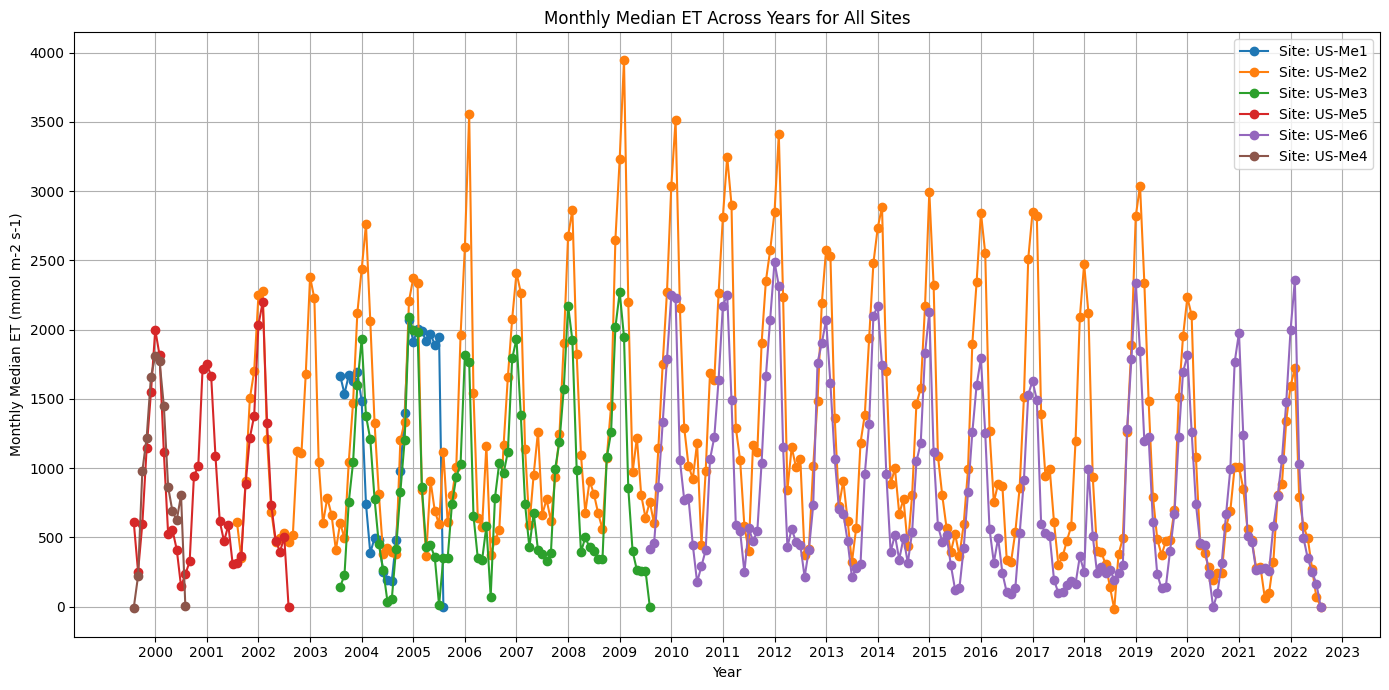

In [ ]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Load the NetCDF file
try:
    ds_xr = xr.open_dataset('fluxnet_estimates_30minc.nc')
except FileNotFoundError:
    print("Error: The file 'fluxnet_estimates_30min.nc' was not found. Please ensure the previous code block was executed successfully.")
    exit()

# Convert the xarray Dataset to a Pandas DataFrame
estimates_df = ds_xr.to_dataframe().reset_index()

# Convert 'time' to datetime objects
estimates_df['time'] = pd.to_datetime(estimates_df['time'])

# Extract the month and year
estimates_df['month'] = estimates_df['time'].dt.month
estimates_df['year'] = estimates_df['time'].dt.year
estimates_df['Site'] = estimates_df['Site'].astype(str)  # Ensure 'Site' is a string

# Get unique sites
sites = estimates_df['Site'].unique()
n_sites = len(sites)

# Calculate the monthly sum ET for each year and site
monthly_sum_et_by_year_site = estimates_df.groupby(['Site', 'year', 'month'])['ET'].sum().unstack(level='month')

# Create the plot
fig, ax = plt.subplots(figsize=(14, 7))  # Only one plot

# Plotting the data for all sites
months = range(1, 13)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Prepare the x-axis for all years >= 2000
all_years = sorted(estimates_df['year'].unique())
all_years = [year for year in all_years if year >= 2000] # Filter for years >= 2000
n_years = len(all_years)
x = np.arange(1, n_years * 12 + 1)
x_ticks = np.arange(6, n_years * 12 + 6, 12)
x_ticklabels = [str(year) for year in all_years]


for site in sites:
    # Get the data for the current site
    site_data = monthly_sum_et_by_year_site.loc[site]

    # Prepare the y-data, handling potential missing years
    y_values = []
    for year in all_years:
        if year in site_data.index:
            y_values.extend(site_data.loc[year].values)
        else:
            y_values.extend([np.nan] * 12)
    y = np.array(y_values)
    
    not_zero_or_nan_mask = (y != 0) & (~np.isnan(y))
    # Plot only the x and y values where y is not 0 and not NaN
    ax.plot(x[not_zero_or_nan_mask], y[not_zero_or_nan_mask], marker='o', linestyle='-', label=f'Site: {site}')

# Customize the plot
ax.set_xlabel('Year')
ax.set_ylabel('Monthly Sum ET (mmol m-2 s-1)')
ax.set_title('Monthly Sum ET Across Years for All Sites')
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticklabels)
ax.grid(True)
ax.legend()  # Add a legend to distinguish the sites
plt.tight_layout()
plt.show()